Phase 1: Pulling 3 years of daily price data of AAPL through yfinance and calculating all required terms.

[*********************100%***********************]  1 of 1 completed


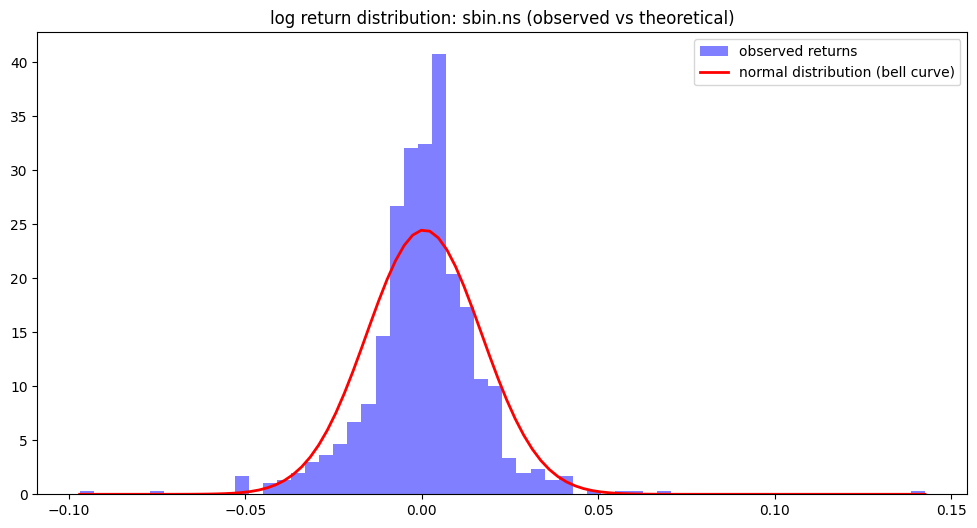

--- benchmark report for AAPL ---
mean daily return:      0.000638
annualised return:      0.1607
annualised volatility:  0.2588
annualised sharpe:      0.6209
max drawdown:           -0.3471
best single day:        0.1426
worst single day:       -0.0970


In [22]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats



# 1. get the data
ticker = "AAPL"
df = yf.download(ticker, period="3y", auto_adjust=True)

# r_t = ln(P_t / P_{t-1})
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df.dropna(inplace=True)

# 3. plotting the distribution vs the normal curve
plt.figure(figsize=(12, 6))
# plot the observed log returns
plt.hist(df['log_return'], bins=60, density=True, alpha=0.5, color='blue', label='observed returns')

# overlay theoretical normal distribution
mu, std = df['log_return'].mean(), df['log_return'].std()
# linespace is taking the range and the no of values it have to plot on x axis
x = np.linspace(df['log_return'].min(), df['log_return'].max(), 100)
# p is the y axis with the norm curve calculating the probabiility density function
p = stats.norm.pdf(x, mu, std)
# r means make the line red
plt.plot(x, p, 'r', linewidth=2, label='normal distribution (bell curve)')

plt.title('log return distribution: sbin.ns (observed vs theoretical)')
plt.legend()
plt.show()

# 4. calculate benchmarks
mean_daily = df['log_return'].mean()
vol_daily = df['log_return'].std()

annualized_return = mean_daily * 252
annualized_vol = vol_daily * np.sqrt(252)
sharpe = annualized_return / annualized_vol  # rf = 0

# max drawdown
#this is cumulativily testing what value of 1 ruppees we will be getting .
cumulative = (1 + df['log_return']).cumprod()
peak = cumulative.cummax()
drawdown = (cumulative - peak) / peak
max_dd = drawdown.min()

# 5. report results
print(f"--- benchmark report for {ticker} ---")
print(f"mean daily return:      {mean_daily:.6f}")
print(f"annualised return:      {annualized_return:.4f}")
print(f"annualised volatility:  {annualized_vol:.4f}")
print(f"annualised sharpe:      {sharpe:.4f}")
print(f"max drawdown:           {max_dd:.4f}")
print(f"best single day:        {df['log_return'].max():.4f}")
print(f"worst single day:       {df['log_return'].min():.4f}")

Phase 2 : Making signals out of hypothesis

---
# .

# Custom strategy 1:
Hypothesis: When a stocks daily return violently deviates by more than +-2.2 standard deviations from its 20-day average [X],
I expect the stock [Y] to mean-revert (snap back in the opposite direction) [Z] over a maximum of the next 2 days or until the Z-score neutralizes below +-0.1 [N],
because moves of this statistical magnitude represent temporary,
unsustainable overreactions (extreme panic or extreme euphoria) that quickly correct themselves as normal market liquidity returns [M].

# .
---

In [36]:
import pandas as pd
import numpy as np
import yfinance as yf

print("Step 1: Fetching 10 years of data for Apple (AAPL)...")
df = yf.download("AAPL", start="2014-01-01", end="2024-01-01", progress=False)

# Clean up the yfinance columns just in case
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()


print("Step 2: Applying your custom Z-Score Strategy...")
# Get the daily return
df['Return'] = df['Close'].pct_change()

# Calculate the 20-day rolling average and bounciness (Standard Deviation)
rolling_mean = df['Return'].rolling(window=20).mean()
rolling_std = df['Return'].rolling(window=20).std()

# Calculate the Z-Score (how weird is today compared to normal?)
df['Z_Score'] = (df['Return'] - rolling_mean) / (rolling_std + 1e-8)

# Define the triggers
long_entry = df['Z_Score'] < -2.2
short_entry = df['Z_Score'] > 2.2
exit_signal = df['Z_Score'].abs() < 0.1  # True if between -0.6 and 0.6

# Build the "Hold for 2 days" logic
is_long_day1 = long_entry
is_short_day1 = short_entry

# Day 2 is active IF yesterday was Day 1 AND we haven't hit the exit zone yet
is_long_day2 = long_entry.shift(1) & ~exit_signal
is_short_day2 = short_entry.shift(1) & ~exit_signal

# Apply the signals to the dataframe
df['Sig_Z_Score'] = 0
df.loc[is_long_day1 | is_long_day2, 'Sig_Z_Score'] = 1
df.loc[is_short_day1 | is_short_day2, 'Sig_Z_Score'] = -1


print("Step 3: Calculating Performance Metrics...")
# Calculate what the strategy actually made (shifting signal by 1 to trade at the close)
df['Strategy_Return'] = df['Sig_Z_Score'].shift(1) * df['Return']

# Drop all the empty rows created by the rolling math so we get a clean grade
clean_df = df.dropna().copy()

# --- Math for the Benchmark (Buy & Hold) ---
b_mean = clean_df['Return'].mean()
b_ann_ret = ((1 + b_mean) ** 252) - 1
b_ann_vol = clean_df['Return'].std() * np.sqrt(252)
b_sharpe = b_ann_ret / b_ann_vol if b_ann_vol != 0 else 0

b_cum_equity = (1 + clean_df['Return']).cumprod()
b_peak = b_cum_equity.cummax()
b_mdd = ((b_cum_equity - b_peak) / b_peak).min()

# --- Math for the Custom Strategy ---
s_mean = clean_df['Strategy_Return'].mean()
s_ann_ret = ((1 + s_mean) ** 252) - 1
s_ann_vol = clean_df['Strategy_Return'].std() * np.sqrt(252)
s_sharpe = s_ann_ret / s_ann_vol if s_ann_vol != 0 else 0

s_cum_equity = (1 + clean_df['Strategy_Return']).cumprod()
s_peak = s_cum_equity.cummax()
s_mdd = ((s_cum_equity - s_peak) / s_peak).min()


print("\nStep 4: The Final Report Card")
print("===========================================================================")
print(f"{'Metric':<25} | {'Benchmark (Buy & Hold)':<22} | {'Your Z-Score Bot':<20}")
print("---------------------------------------------------------------------------")
print(f"{'Annualised Return':<25} | {b_ann_ret*100:>21.2f}% | {s_ann_ret*100:>19.2f}%")
print(f"{'Annualised Volatility':<25} | {b_ann_vol*100:>21.2f}% | {s_ann_vol*100:>19.2f}%")
print(f"{'Sharpe Ratio':<25} | {b_sharpe:>22.2f} | {s_sharpe:>20.2f}")
print(f"{'Maximum Drawdown':<25} | {b_mdd*100:>21.2f}% | {s_mdd*100:>19.2f}%")
print("===========================================================================\n")

Step 1: Fetching 10 years of data for Apple (AAPL)...
Step 2: Applying your custom Z-Score Strategy...
Step 3: Calculating Performance Metrics...

Step 4: The Final Report Card
Metric                    | Benchmark (Buy & Hold) | Your Z-Score Bot    
---------------------------------------------------------------------------
Annualised Return         |                 34.10% |                4.33%
Annualised Volatility     |                 28.31% |                9.07%
Sharpe Ratio              |                   1.20 |                 0.48
Maximum Drawdown          |                -38.52% |              -17.27%



/tmp/ipykernel_6698/2217740787.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2014-01-01", end="2024-01-01", progress=False)


---
# .

# Custom Strategy 2:
Hypothesis:
When a stock either breaks out of its 20-day volatility range (Z-score > ±0.8) in the direction of its 50-day macro trend, OR pivots after reaching extreme statistical exhaustion (Z-score > ±2.0) [X], I expect the stock [Y] to trend strongly in the direction of the trigger [Z] until its momentum decays by 0.5 standard deviations [N], because trend-aligned breakouts capture sustained institutional momentum, while fading extreme statistical deviations catches the exact moment an unsustainable overreaction snaps back to the mean [M].

#.
---

In [35]:
import pandas as pd
import numpy as np
import yfinance as yf

print("Step 1: Fetching 10 years of data for Apple (AAPL)...")
df = yf.download("AAPL", start="2014-01-01", end="2024-01-01", progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

print("Step 2: Calculating Z-Scores and Trend Filters...")
df['Return'] = df['Close'].pct_change()

# 1. Z-Score (Price Extremes)
rolling_mean = df['Close'].rolling(window=20).mean()
rolling_std = df['Close'].rolling(window=20).std()
df['Z_Score'] = (df['Close'] - rolling_mean) / (rolling_std + 1e-8)

# 2. Macro Trend Filter (The 50-day moving average)
df['SMA_50'] = df['Close'].rolling(window=50).mean()

df = df.dropna().copy()

print("Step 3: Running the Upgraded State Machine Bot...")
z_scores = df['Z_Score'].values
closes = df['Close'].values
sma50 = df['SMA_50'].values

signals = np.zeros(len(df))

state = 0
peak_z = 0.0
trough_z = 0.0

for i in range(1, len(df)):
    current_z = z_scores[i]
    prev_z = z_scores[i-1]

    current_close = closes[i]
    prev_close = closes[i-1]
    current_sma = sma50[i]

    # ==========================================
    # LOOKING FOR ENTRIES (If we are in Cash)
    # ==========================================
    if state == 0:

        # Rule 1: Momentum Long (Breakout above 0.8 AND macro trend is UP)
        if (prev_z < 0.8) and (current_z >= 0.8) and (current_close > current_sma):
            state = 1
            peak_z = current_z
            signals[i] = 1
            continue

        # Rule 2: Exhaustion Long (Extreme panic below -2.0, but today it pivoted UP)
        if (prev_z <= -2.0) and (current_close > prev_close):
            state = 2
            peak_z = current_z
            signals[i] = 1
            continue

        # Rule 3: Momentum Short (Breakout below -0.8 AND macro trend is DOWN)
        if (prev_z > -0.8) and (current_z <= -0.8) and (current_close < current_sma):
            state = -1
            trough_z = current_z
            signals[i] = -1
            continue

        # Rule 4: Exhaustion Short (Extreme hype above 2.0, but today it pivoted DOWN)
        if (prev_z >= 2.0) and (current_close < prev_close):
            state = -2
            trough_z = current_z
            signals[i] = -1
            continue

    # ==========================================
    # MANAGING EXITS (Wider Trailing Stops to let winners run)
    # ==========================================
    elif state == 1 or state == 2: # In ANY Long Position
        signals[i] = 1
        peak_z = max(peak_z, current_z)

        # Exit if Z-Score drops by 0.5 from the highest point, OR reverts to 0
        if current_z <= (peak_z - 0.5) or current_z < 0:
            state = 0

    elif state == -1 or state == -2: # In ANY Short Position
        signals[i] = -1
        trough_z = min(trough_z, current_z)

        # Exit if Z-Score bounces by 0.5 from the lowest point, OR reverts to 0
        if current_z >= (trough_z + 0.5) or current_z > 0:
            state = 0

# Attach signals
df['Sig_Improved_Machine'] = signals

print("Step 4: Calculating Performance Metrics...")
df['Strategy_Return'] = df['Sig_Improved_Machine'].shift(1) * df['Return']
clean_df = df.dropna().copy()

b_ann_ret = ((1 + clean_df['Return'].mean()) ** 252) - 1
b_ann_vol = clean_df['Return'].std() * np.sqrt(252)
b_sharpe = b_ann_ret / b_ann_vol if b_ann_vol != 0 else 0
b_cum_eq = (1 + clean_df['Return']).cumprod()
b_mdd = ((b_cum_eq - b_cum_eq.cummax()) / b_cum_eq.cummax()).min()

s_ann_ret = ((1 + clean_df['Strategy_Return'].mean()) ** 252) - 1
s_ann_vol = clean_df['Strategy_Return'].std() * np.sqrt(252)
s_sharpe = s_ann_ret / s_ann_vol if s_ann_vol != 0 else 0
s_cum_eq = (1 + clean_df['Strategy_Return']).cumprod()
s_mdd = ((s_cum_eq - s_cum_eq.cummax()) / s_cum_eq.cummax()).min()

print("\n===========================================================================")
print(f"{'Metric':<25} | {'Benchmark (Buy & Hold)':<22} | {'Improved State Machine':<20}")
print("---------------------------------------------------------------------------")
print(f"{'Annualised Return':<25} | {b_ann_ret*100:>21.2f}% | {s_ann_ret*100:>19.2f}%")
print(f"{'Annualised Volatility':<25} | {b_ann_vol*100:>21.2f}% | {s_ann_vol*100:>19.2f}%")
print(f"{'Sharpe Ratio':<25} | {b_sharpe:>22.2f} | {s_sharpe:>20.2f}")
print(f"{'Maximum Drawdown':<25} | {b_mdd*100:>21.2f}% | {s_mdd*100:>19.2f}%")
print("===========================================================================\n")

Step 1: Fetching 10 years of data for Apple (AAPL)...
Step 2: Calculating Z-Scores and Trend Filters...
Step 3: Running the Upgraded State Machine Bot...
Step 4: Calculating Performance Metrics...

Metric                    | Benchmark (Buy & Hold) | Improved State Machine
---------------------------------------------------------------------------
Annualised Return         |                 33.81% |                2.21%
Annualised Volatility     |                 28.44% |               17.30%
Sharpe Ratio              |                   1.19 |                 0.13
Maximum Drawdown          |                -38.52% |              -36.05%



/tmp/ipykernel_6698/243763856.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2014-01-01", end="2024-01-01", progress=False)


---
# .
# .
# .

---
# Some strategies got from ai for comparision purposes.
---


# .
# .
# .
---

# Quantitative Trading Hypotheses Master List

## Bullish Strategies (Going Long)

**Signal 1: Mean Reversal (Panic Absorption)**
* **Hypothesis:** When a stock hits a 20-day low intraday but closes in the top 25% of its daily range on more than 2x average volume [X], I expect the stock [Y] to rally [Z] over the next 5 days [N], because the extreme volume and long lower wick indicate that forced panic selling was fully absorbed by institutional buyers, leaving a vacuum of sellers in the near term [M].

**Signal 2: Volatility Squeeze Breakout**
* **Hypothesis:** When a stock's daily high-low range has been below its 20-day average for 4 days, followed by a close breaking a 10-day high on 1.5x average volume [X], I expect the stock [Y] to trend higher [Z] over the next 10 days [N], because the period of low volatility indicates an equilibrium where sellers dried up, and the sudden high-volume breakout signals aggressive new accumulation [M].

**Signal 3: The Institutional Pocket**
* **Hypothesis:** When an asset makes a new 20-day high, pulls back for 2 to 3 consecutive days on declining volume, and then prints a single positive day on 2x average volume [X], I expect the asset [Y] to resume its upward trend [Z] over the next 5 days [N], because the massive volume surge on a shallow pullback indicates institutional buyers are actively defending their positions and absorbing residual supply [M].

**Signal 4: The Inside Bar Squeeze**
* **Hypothesis:** When an asset prints an 'Inside Bar' on volume less than 60% of average, followed immediately by a day breaking above the inside bar's high [X], I expect the asset [Y] to accelerate upward [Z] over the next 5 days [N], because the inside bar represents an absolute standstill in volatility, and the subsequent high breakout forces trapped short-sellers to buy back their shares to cover losses [M].

**Signal 5: The Capitulation V-Bottom**
* **Hypothesis:** When a stock falls for 5 consecutive days, printing a massive red candle on 3x average volume, followed immediately by a green candle that closes above the previous day's high [X], I expect the stock [Y] to rebound strongly [Z] over the next 5 days [N], because the extreme volume on the down-day represents final capitulation, leaving an empty vacuum of sellers and allowing buyers to easily drive the price up [M].

**Signal 6: The Silent Accumulation**
* **Hypothesis:** When a stock trades in a tight 5% range for 10 days, but the average volume on 'up-days' is at least 50% higher than on 'down-days' [X], I expect the stock [Y] to break out upwards [Z] over the next 10 days [N], because institutions are quietly absorbing supply and building a large position carefully without alerting the broader market [M].

---

## Bearish Strategies (Going Short)

**Signal 7: The Retail Gap Trap**
* **Hypothesis:** When a stock gaps up more than 3% at the open but closes the day below its open price on higher-than-average volume [X], I expect the stock [Y] to decline [Z] over the next 3 days [N], because institutional players used the artificial liquidity of the retail morning gap to offload their shares, trapping recent buyers who will be forced to sell to cut losses [M].

**Signal 8: The Buying Exhaustion Climax**
* **Hypothesis:** When an asset has closed positive for 4 consecutive days, gaps up to a new 50-day high, but closes in the bottom 25% of its daily range on the highest volume of the last 50 days [X], I expect the asset [Y] to decline sharply [Z] over the next 5

In [42]:
import pandas as pd
import numpy as np

def generate_signals(df):
    """
    Takes a DataFrame with columns: ['Open', 'High', 'Low', 'Close', 'Volume']
    and adds signal columns for 9 quantitative strategies.
    Signal = 1 (Go Long), Signal = -1 (Go Short), Signal = 0 (Flat/Cash)
    """
    # Pre-calculate common rolling metrics to save time
    range_ = df['High'] - df['Low']
    vol_20_avg = df['Volume'].rolling(20).mean()
    vol_30_avg = df['Volume'].rolling(30).mean()

    # 1. The Panic Absorption
    is_20d_low = df['Low'] == df['Low'].rolling(20).min()
    close_top_25 = df['Close'] > (df['Low'] + 0.75 * range_)
    vol_spike_30 = df['Volume'] > (2 * vol_30_avg)
    df['Sig_Panic_Absorption'] = (is_20d_low & close_top_25 & vol_spike_30).astype(int)

    # 2. The Volatility Squeeze Breakout
    avg_range_20 = range_.rolling(20).mean()
    tight_4_days = (range_ < avg_range_20).rolling(4).sum() == 4
    breakout = df['Close'] > df['High'].rolling(10).max().shift(1)
    vol_spike_20 = df['Volume'] > (1.5 * vol_20_avg)
    df['Sig_Vol_Squeeze'] = (tight_4_days.shift(1) & breakout & vol_spike_20).astype(int)

    # 3. The Institutional Pocket
    two_red_days = (df['Close'] < df['Open']).rolling(2).sum() == 2
    green_today = df['Close'] > df['Open']
    df['Sig_Inst_Pocket'] = (two_red_days.shift(1) & green_today & (df['Volume'] > 2 * vol_20_avg)).astype(int)

    # 4. The Inside Bar Squeeze
    inside_bar = (df['High'] < df['High'].shift(1)) & (df['Low'] > df['Low'].shift(1))
    low_vol = df['Volume'] < (0.6 * vol_20_avg)
    breakout_inside = df['Close'] > df['High'].shift(1)
    df['Sig_Inside_Bar'] = (inside_bar.shift(1) & low_vol.shift(1) & breakout_inside).astype(int)

    # 5. The Capitulation V-Bottom
    five_red_days = (df['Close'] < df['Open']).rolling(5).sum() == 5
    crash_vol = df['Volume'] > (3 * vol_20_avg)
    engulfing_green = df['Close'] > df['High'].shift(1)
    df['Sig_V_Bottom'] = (five_red_days.shift(1) & crash_vol.shift(1) & engulfing_green).astype(int)

    # 6. The Silent Accumulation
    ten_day_high = df['High'].rolling(10).max()
    ten_day_low = df['Low'].rolling(10).min()
    tight_range = ((ten_day_high - ten_day_low) / ten_day_low) < 0.05

    is_up = df['Close'] > df['Open']
    is_down = df['Close'] < df['Open']
    avg_up_vol = (df['Volume'] * is_up).rolling(10).sum() / is_up.rolling(10).sum().replace(0, 1)
    avg_down_vol = (df['Volume'] * is_down).rolling(10).sum() / is_down.rolling(10).sum().replace(0, 1)

    df['Sig_Silent_Acc'] = (tight_range & (avg_up_vol > 1.5 * avg_down_vol)).astype(int)

    # ---------------------------------------------------------
    # BEARISH STRATEGIES (SHORT: expected_direction='down')
    # ---------------------------------------------------------

    # 7. The Retail Gap Trap
    gap_up_3pct = df['Open'] > (df['Close'].shift(1) * 1.03)
    closed_red = df['Close'] < df['Open']
    df['Sig_Gap_Trap'] = (gap_up_3pct & closed_red & (df['Volume'] > vol_20_avg)).astype(int) * -1

    # 8. The Buying Exhaustion Climax
    four_green_days = (df['Close'] > df['Open']).rolling(4).sum() == 4
    hit_50d_high = df['High'] == df['High'].rolling(50).max()
    close_bottom_25 = df['Close'] < (df['Low'] + 0.25 * range_)
    highest_vol_50 = df['Volume'] == df['Volume'].rolling(50).max()
    df['Sig_Exhaustion'] = (four_green_days.shift(1) & hit_50d_high & close_bottom_25 & highest_vol_50).astype(int) * -1

    # 9. The Bull Trap Fakeout
    broke_50d_high = df['High'] > df['High'].rolling(50).max().shift(1)
    closed_lower_than_yest = df['Close'] < df['Close'].shift(1)
    df['Sig_Bull_Trap'] = (broke_50d_high & closed_lower_than_yest & (df['Volume'] > 2 * vol_20_avg)).astype(int) * -1

    return df

## We have created a signal generation funcion now to evaluate it on:
Average return over the next 5 trading days in each signal state.
- Does the direction match what th hypothesis predicted?
- Annualised return
- Annualised Sharpe ratio
- Maximum drawdown

In [27]:
def evaluate_strategy(df, signal_column, expected_direction='up'):
    """
    Evaluates a specific trading signal against the Buy & Hold benchmark.
    expected_direction: 'up' for Long strategies, 'down' for Short strategies.
    """
    # 1. Calculate Daily Returns
    df['Asset_Return'] = df['Close'].pct_change()

    # Strategy Return: Shift signal by 1 to simulate trading at the close
    df['Strategy_Return'] = df[signal_column].shift(1) * df['Asset_Return']

    # 2. Calculate 5-Day Forward Returns (shift(-5) pulls future return to today)
    df['Fwd_5d_Return'] = df['Close'].pct_change(periods=5).shift(-5)

    # Drop NaNs to ensure clean math
    clean_df = df.dropna().copy()

    # If the signal never triggered, exit early
    if not (clean_df[signal_column] != 0).any():
        print(f"=== STRATEGY EVALUATION: {signal_column} ===")
        print("NO SIGNALS TRIGGERED in this dataset.\n")
        return

    # PART A: HYPOTHESIS & FORWARD RETURN CHECK
    print(f"=== STRATEGY EVALUATION: {signal_column} ===")
    print("1. Average Return over the next 5 trading days in each signal state:")

    fwd_returns = clean_df.groupby(signal_column)['Fwd_5d_Return'].mean() * 100

    for state, ret in fwd_returns.items():
        if state == 1:
            state_name = "Signal ON (Long)"
        elif state == -1:
            state_name = "Signal ON (Short)"
        else:
            state_name = "Signal OFF (Flat)"
        print(f"   {state_name:<18}: {ret:>6.2f}%")

    print("\n   Does the direction match what your hypothesis predicted?")
    if 1 in fwd_returns.index and expected_direction == 'up':
        matched = "YES" if fwd_returns[1] > 0 else "NO"
        print(f"   Predicted UP. Actual average was {fwd_returns[1]:.2f}%. Match: {matched}")
    elif -1 in fwd_returns.index and expected_direction == 'down':
        matched = "YES" if fwd_returns[-1] < 0 else "NO"
        print(f"   Predicted DOWN. Actual average was {fwd_returns[-1]:.2f}%. Match: {matched}")


    def get_metrics(returns_series):
        mean_daily = returns_series.mean()
        ann_return = ((1 + mean_daily) ** 252) - 1
        ann_vol = returns_series.std() * np.sqrt(252)
        sharpe = ann_return / ann_vol if ann_vol != 0 else 0

        cum_equity = (1 + returns_series).cumprod()
        peak = cum_equity.cummax()
        drawdown = (cum_equity - peak) / peak
        max_dd = drawdown.min()

        return ann_return, ann_vol, sharpe, max_dd

    bench_ret, bench_vol, bench_sharpe, bench_mdd = get_metrics(clean_df['Asset_Return'])
    strat_ret, strat_vol, strat_sharpe, strat_mdd = get_metrics(clean_df['Strategy_Return'])

    print("\n2. Core Metrics vs Benchmark (Side-by-Side):")
    print("-" * 75)
    print(f"{'Metric':<25} | {'Benchmark (Buy & Hold)':<22} | {'Active Strategy':<20}")
    print("-" * 75)
    print(f"{'Annualised Return':<25} | {bench_ret*100:>21.2f}% | {strat_ret*100:>19.2f}%")
    print(f"{'Annualised Volatility':<25} | {bench_vol*100:>21.2f}% | {strat_vol*100:>19.2f}%")
    print(f"{'Annualised Sharpe Ratio':<25} | {bench_sharpe:>22.2f} | {strat_sharpe:>20.2f}")
    print(f"{'Maximum Drawdown':<25} | {bench_mdd*100:>21.2f}% | {strat_mdd*100:>19.2f}%")
    print("=" * 75 + "\n")



# ==========================================
# 3. AUTOMATED EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    print("Fetching 10 years of historical data for Apple (AAPL)...")

    # Download the data
    df = yf.download("AAPL", start="2014-01-01", end="2024-01-01", progress=False)

    # Fix yfinance MultiIndex columns if necessary
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Ensure standard column names
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

    print("Generating Signals for all 9 strategies...\n")
    df = generate_signals(df)

    # ---------------------------------------------------------
    # Strategy Configuration Setup
    # Format: (Signal_Column_Name, Expected_Direction, Readable_Name)
    # ---------------------------------------------------------
    strategies_to_test = [
        # Bullish (Long) Strategies
        ('Sig_Panic_Absorption', 'up',   '1. The Panic Absorption (Mean Reversion)'),
        ('Sig_Vol_Squeeze',      'up',   '2. The Volatility Squeeze (Momentum)'),
        ('Sig_Inst_Pocket',      'up',   '3. The Institutional Pocket (Trend)'),
        ('Sig_Inside_Bar',       'up',   '4. The Inside Bar Squeeze (Breakout)'),
        ('Sig_V_Bottom',         'up',   '5. The Capitulation V-Bottom (Reversal)'),
        ('Sig_Silent_Acc',       'up',   '6. The Silent Accumulation (Pre-Breakout)'),

        # Bearish (Short) Strategies
        ('Sig_Gap_Trap',         'down', '7. The Retail Gap Trap (Gap Reversal)'),
        ('Sig_Exhaustion',       'down', '8. The Buying Exhaustion Climax (Top Fade)'),
        ('Sig_Bull_Trap',        'down', '9. The Bull Trap Fakeout (False Breakout)')
    ]

    print("==========================================================")
    print("          AUTOMATED STRATEGY EVALUATION REPORT            ")
    print("==========================================================\n")

    # Loop through the list and evaluate every strategy automatically
    for column_name, direction, display_name in strategies_to_test:
        print(f"Testing Strategy: {display_name.upper()}")
        evaluate_strategy(df, column_name, expected_direction=direction)

    print("==========================================================")
    print("                   EVALUATION COMPLETE                    ")
    print("==========================================================")


Fetching 10 years of historical data for Apple (AAPL)...
Generating Signals for all 9 strategies...

          AUTOMATED STRATEGY EVALUATION REPORT            

Testing Strategy: 1. THE PANIC ABSORPTION (MEAN REVERSION)
=== STRATEGY EVALUATION: Sig_Panic_Absorption ===
1. Average Return over the next 5 trading days in each signal state:
   Signal OFF (Flat) :   0.55%
   Signal ON (Long)  :   2.06%

   Does the direction match what your hypothesis predicted?
   Predicted UP. Actual average was 2.06%. Match: YES

2. Core Metrics vs Benchmark (Side-by-Side):
---------------------------------------------------------------------------
Metric                    | Benchmark (Buy & Hold) | Active Strategy     
---------------------------------------------------------------------------
Annualised Return         |                 32.74% |                1.28%
Annualised Volatility     |                 28.41% |                3.07%
Annualised Sharpe Ratio   |                   1.15 |            

/tmp/ipykernel_6698/1774143345.py:83: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2014-01-01", end="2024-01-01", progress=False)
